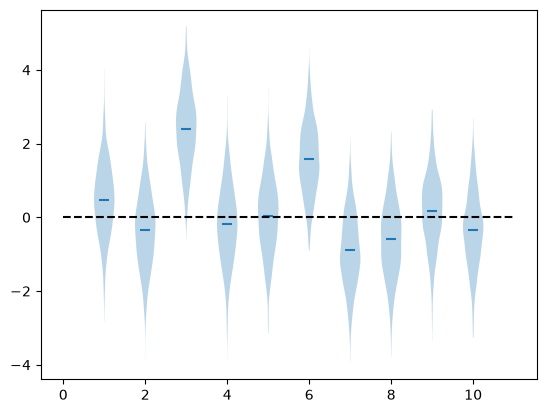

In [2]:
# library import

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(5)       # fixing the randomization seed

# initialization

k=10;                   # number of arms

q_star=np.random.normal(0,1,k);     # average reward in each arm
sigma=np.ones(k);                   # variance of reward for each arm

data=[np.random.normal(q_star[i],sigma[i],1000) for i in range(0,k)];

plt.violinplot(data,showextrema=False, showmeans=True);
plt.plot([0,11],[0,0],linestyle='dashed',color='black')

plt.savefig('arms.png')
plt.show()


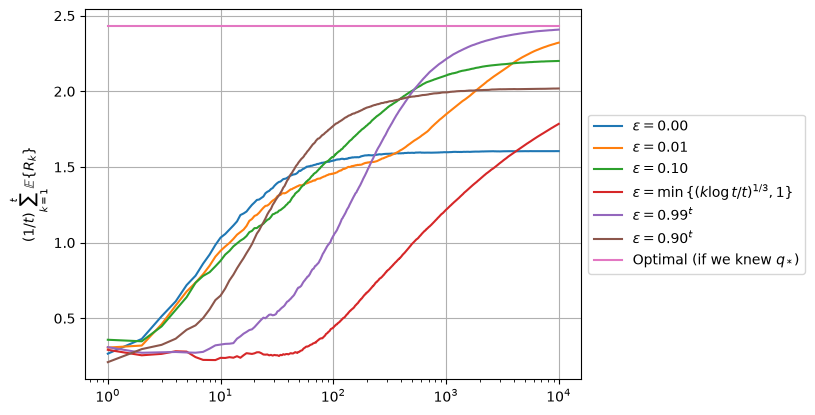

In [3]:
# epsilon-greedy bandit

T=10000;                            # horizon
rerun=100;                          # number of reruns

legend=[];
for scenario in range(6):       # we test 6 scenarios:
                                # 3 with fixed epsilon and
                                # 3 with time varying epsilon
    
    R=np.zeros((T,rerun));			# rewards received
    average=np.zeros(T);         	# average reward over time

    match scenario:
        case 0:                     	# scenario 0: epsilon fixed to 0
            epsilon_t=lambda t: 0;
            legend.append(r'$\epsilon=0.00$');
        case 1:                     	# scenario 1: epsilon fixed to 0.01
            epsilon_t=lambda t: 0.01;
            legend.append(r'$\epsilon=0.01$');
        case 2:                     	# scenario 2: epsilon fixed to 0.1
            epsilon_t=lambda t: 0.1;
            legend.append(r'$\epsilon=0.10$');
        case 3:                     	# scenario 3: epsilon varying (slides)
            epsilon_t=lambda t: min((k*np.log(t+1)/(t+1))**(1/3),1);
            legend.append(r'$\epsilon=\min\{(k \log t/t)^{1/3},1\}$');
        case 4:                     	# scenario 4: epsilon diminishing 
            epsilon_t=lambda t: 0.99**t;# exponentially (slowly)
            legend.append(r'$\epsilon=0.99^t$');
        case 5:                     	# scenario 5: epsilon diminishing
            epsilon_t=lambda t: 0.90**t;# exponentially (quicker)  -- fixed: was 0.99**t
            legend.append(r'$\epsilon=0.90^t$');

    for r in range(0,rerun):
        Q=np.zeros((k,T+1));        # empirical mean
        N=np.zeros((k,T+1));        # number of times an arm used
        A=np.zeros(T,dtype=int);    # arms used

        for t in range(0,T):
            epsilon=epsilon_t(t);

            if (np.random.uniform()<epsilon):
                A[t]=int(np.random.randint(0,k));   # exploration
            else:
                A[t]=int(np.argmax(Q[:,t]));		#exploitation

            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);

            for i in range(0,k):
                N[i,t+1]=N[i,t];
                Q[i,t+1]=Q[i,t];
                if (A[t]==i):
                    N[i,t+1]=N[i,t]+1;
                    Q[i,t+1]=Q[i,t]+(1/N[i,t+1])*(R[t,r]-Q[i,t]);

    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)

    plt.semilogx(range(1,T),average[1:T]);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('epsilon.png',bbox_inches='tight')
plt.show()


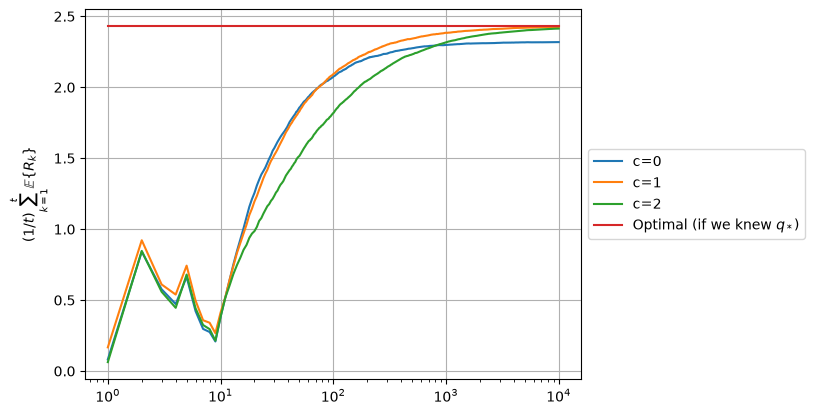

In [4]:
# Upper-Confidence Bound (UCB)

T=10000;                          # horizon
rerun=100;                        # number of reruns

legend=[];
for scenario in range(3):
    R=np.zeros((T,rerun));        # rewards received
    average=np.zeros(T);          # average reward over time
    
    match scenario:
        case 0:                   # scenario 0: c=0 (no exploration)
            c=0;
            legend.append('c=0');
        case 1:                   # scenario 1: c=1 
            c=1;
            legend.append('c=1');
        case 2:                   # scenario 2: c=2
            c=2;
            legend.append('c=2');
    
    for r in range(0,rerun):
        Q=np.zeros((k,T+1));        # empirical mean
        N=np.zeros((k,T+1));        # number of times an arm used
        A=np.zeros(T,dtype=int);    # arms used
        
        for t in range(0,T):
            if t < k:
                A[t] = t                       # fixed: pull each arm once first,
            else:                               # avoids 0/0 = nan in the UCB term at t=0
                A[t]=int(np.argmax(Q[:,t]+c*np.sqrt(np.log(t+1)/N[:,t])));
            
            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);
            
            for i in range(0,k):
                N[i,t+1]=N[i,t];
                Q[i,t+1]=Q[i,t];
                if (A[t]==i):
                    N[i,t+1]=N[i,t]+1;
                    Q[i,t+1]=Q[i,t]+(1/N[i,t+1])*(R[t,r]-Q[i,t]);
    
    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)
    
    plt.semilogx(range(1,T),average[1:T]);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('UCB.png',bbox_inches='tight')
plt.show()


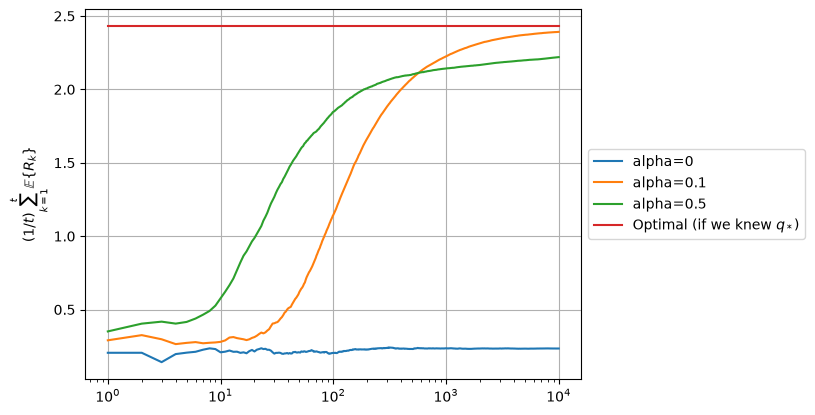

In [7]:
# Gradient bandit algorithm

T=10000;                          # horizon
rerun=100;                        # number of reruns

legend=[];
for scenario in range(3):
    R=np.zeros((T,rerun));        # rewards received
    average=np.zeros(T);          # average reward over time

    match scenario:
        case 0:                   # scenario 0: alpha=0 (no learning)
            alpha=0;
            legend.append('alpha=0');
        case 1:                   # scenario 1: alpha=0.1
            alpha=0.1;
            legend.append('alpha=0.1');
        case 2:                   # scenario 2: alpha=0.5
            alpha=0.5;
            legend.append('alpha=0.5');

    for r in range(0,rerun):
        H=np.zeros((k,T+1));      # numerical preference
        P=np.zeros((k,T+1));      # policy (probability of each action)
        A=np.zeros(T,dtype=int);  # arms used
        bR=0;                     # average rewards in the past (baseline)

        for t in range(0,T):
            P[:,t]=np.exp(H[:,t])/np.sum(np.exp(H[:,t]));
            
            A[t]=np.random.choice(range(k), p=P[:,t]);
            
            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);
            
            for i in range(0,k):
                H[i,t+1]=H[i,t]-alpha*P[i,t]*(R[t,r]-bR);
                if (A[t]==i):
                    H[i,t+1]=H[i,t]+alpha*(1-P[i,t])*(R[t,r]-bR);
            
            bR=bR*t/(t+1)+R[t,r]/(t+1);

    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)
    
    plt.semilogx(range(1,T),average[1:T]);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('gradient.png',bbox_inches='tight')
plt.show()
